<a href="https://colab.research.google.com/github/MandakiniTraning/PINN/blob/main/Genetic_Toggle_Switch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install diffrax

In [5]:
import jax
import jax.numpy as jnp
from jax import random
import diffrax  # JAX-native ODE solver (pip install diffrax)
import optax    # JAX optimizer

# --------------------- Toggle Switch ODE ---------------------
def toggle_switch(t, y, args):
    # y = [x1, x2]  (expression of gene 1 and gene 2)
    # args = [beta, gamma, alpha, n]  (production rate, degradation, repression strength, Hill coefficient)
    beta, gamma, alpha, n = args
    x1, x2 = y

    dx1 = beta / (1 + (x2 / alpha)**n) - gamma * x1
    dx2 = beta / (1 + (x1 / alpha)**n) - gamma * x2
    return jnp.array([dx1, dx2])

# JAX-wrapped solver (Diffrax)
def simulate_toggle(initial_state, args, t_end=50.0, n_steps=200):
    ts = jnp.linspace(0.0, t_end, n_steps)
    solution = diffrax.diffeqsolve(
        diffrax.ODETerm(toggle_switch),
        diffrax.Tsit5(),          # high-order solver
        t0=0.0, t1=t_end,
        dt0=0.1,
        y0=initial_state,
        args=args,
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-6, atol=1e-8)
    )
    return solution.ys   # shape: (n_steps, 2)

# Vectorized version (simulate many networks at once)
simulate_toggle_vmap = jax.vmap(simulate_toggle, in_axes=(0, None))

# --------------------- Prediction + Loss (for optimization) ---------------------
@jax.jit
def loss_fn(params, initial_states):
    # params = [beta, gamma, alpha, n] — we optimize these
    trajectories = simulate_toggle_vmap(initial_states, params)  # batch over initial conditions
    final_states = trajectories[:, -1, :]                        # look at steady-state

    # Example objective: maximize bistability (one gene high, the other low)
    # + penalize unstable or symmetric states
    diff = jnp.abs(final_states[:, 0] - final_states[:, 1])
    penalty = jnp.mean((final_states[:, 0] + final_states[:, 1] - 10.0)**2)  # keep total expression reasonable
    return -jnp.mean(diff) + 0.1 * penalty   # minimize this → find good parameters

# --------------------- Gradient-based optimization (network-based prediction) ---------------------
key = random.PRNGKey(42)
num_trials = 32
initial_states = random.uniform(key, (num_trials, 2), minval=0.1, maxval=5.0)  # many starting points

# Initial guess for network parameters
params = jnp.array([2.0, 0.5, 1.0, 2.0])          # beta, gamma, alpha, n

optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)

@jax.jit
def update(params, opt_state):
    grads = jax.grad(loss_fn)(params, initial_states)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state

print("Optimizing toggle-switch parameters with JAX...")
for step in range(300):
    params, opt_state = update(params, opt_state)
    if step % 50 == 0:
        loss = loss_fn(params, initial_states)
        print(f"Step {step:3d} | Loss: {loss:.4f} | Params: {params}")

print("\nOptimized parameters:", params)
# Now you can simulate the final network → predict its dynamic behavior!

Optimizing toggle-switch parameters with JAX...
Step   0 | Loss: -2.8118 | Params: [2.0999994  0.40000066 0.9000007  2.0999994 ]
Step  50 | Loss: -12.3284 | Params: [3.5945668  0.22054493 0.53346884 2.714159  ]
Step 100 | Loss: -12.4966 | Params: [3.6611412  0.24523643 0.55481225 2.805641  ]
Step 150 | Loss: -12.4978 | Params: [3.664119   0.24421874 0.5546286  2.8864634 ]
Step 200 | Loss: -12.4982 | Params: [3.664443   0.24429247 0.5543106  2.9610062 ]
Step 250 | Loss: -12.4986 | Params: [3.6648557 0.244313  0.5540152 3.0283551]

Optimized parameters: [3.665277   0.24434228 0.5537482  3.087929  ]


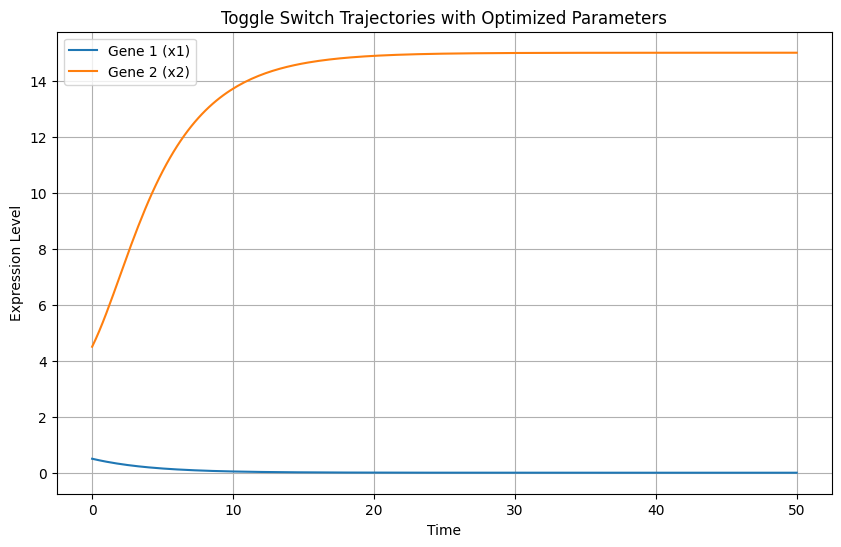

In [6]:
import matplotlib.pyplot as plt

# Optimized parameters from previous run
optimized_params = params

# Define a new initial state for simulation (e.g., starting from low x1, high x2)
# Or we can use one of the initial states used for optimization
initial_state_for_plot = jnp.array([0.5, 4.5]) # Example: low x1, high x2

# Simulate the toggle switch with optimized parameters
solution_plot = simulate_toggle(initial_state_for_plot, optimized_params)

# Extract x1 and x2 trajectories
x1_trajectory = solution_plot[:, 0]
x2_trajectory = solution_plot[:, 1]

# Generate time points for plotting
t_end = 50.0
n_steps = 200
ts_plot = jnp.linspace(0.0, t_end, n_steps)

# Plot the trajectories
plt.figure(figsize=(10, 6))
plt.plot(ts_plot, x1_trajectory, label='Gene 1 (x1)')
plt.plot(ts_plot, x2_trajectory, label='Gene 2 (x2)')
plt.xlabel('Time')
plt.ylabel('Expression Level')
plt.title('Toggle Switch Trajectories with Optimized Parameters')
plt.legend()
plt.grid(True)
plt.show()


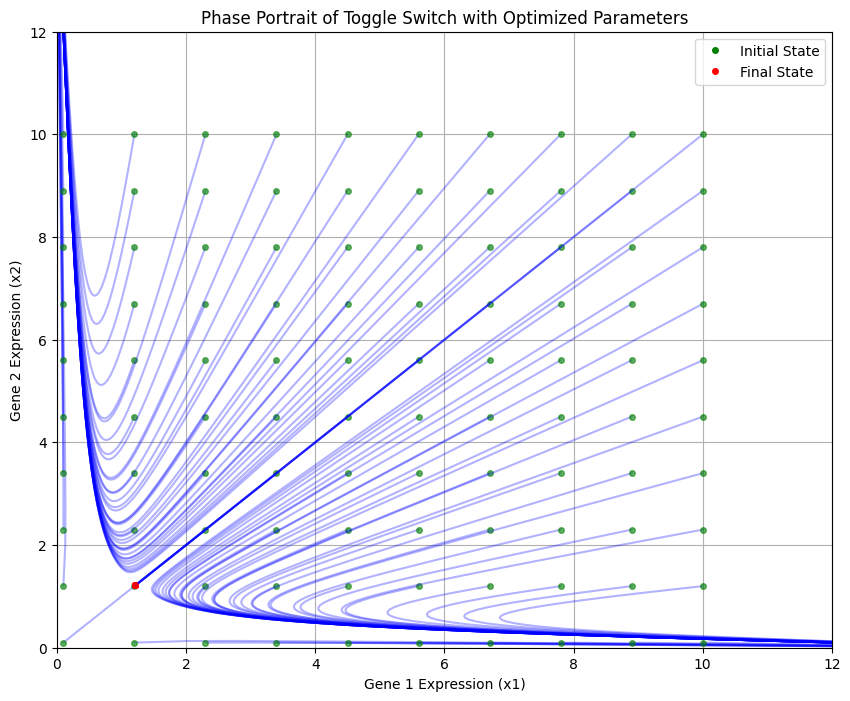

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ranges for x1 and x2 for the initial conditions
x1_range = jnp.linspace(0.1, 10.0, 10) # 10 different initial values for x1
x2_range = jnp.linspace(0.1, 10.0, 10) # 10 different initial values for x2

# Create a grid of initial conditions
initial_conditions_grid = []
for x1_init in x1_range:
    for x2_init in x2_range:
        initial_conditions_grid.append(jnp.array([x1_init, x2_init]))

initial_conditions_grid = jnp.array(initial_conditions_grid) # Convert list to JAX array

# Vectorize simulation for multiple initial conditions
simulate_multiple_ics = jax.vmap(simulate_toggle, in_axes=(0, None))

# Simulate all trajectories with optimized parameters
# Note: This will be a batch of initial_conditions, so we need simulate_multiple_ics
all_trajectories = simulate_multiple_ics(initial_conditions_grid, optimized_params)

# Plotting the phase portrait
plt.figure(figsize=(10, 8))
for i in range(len(initial_conditions_grid)):
    x1_traj = all_trajectories[i, :, 0]
    x2_traj = all_trajectories[i, :, 1]
    plt.plot(x1_traj, x2_traj, color='blue', alpha=0.3)
    # Optionally, plot initial and final points to see direction
    plt.plot(x1_traj[0], x2_traj[0], 'go', markersize=4, alpha=0.6) # Start point (green)
    plt.plot(x1_traj[-1], x2_traj[-1], 'ro', markersize=4, alpha=0.6) # End point (red)

plt.xlabel('Gene 1 Expression (x1)')
plt.ylabel('Gene 2 Expression (x2)')
plt.title('Phase Portrait of Toggle Switch with Optimized Parameters')
plt.grid(True)
plt.xlim(0, 12) # Adjust limits as needed
plt.ylim(0, 12) # Adjust limits as needed

# Add a legend for start/end points
plt.plot([], [], 'go', markersize=4, label='Initial State')
plt.plot([], [], 'ro', markersize=4, label='Final State')
plt.legend()
plt.show()
